## Pyglet
ist ein OpenGL Package. Tutorial [hier](https://greendalecs.wordpress.com/2012/04/21/3d-programming-in-python-part-1/) her.<br>
Gutes PDF (OpenGL in Java) [hier](http://www.cs.cornell.edu/courses/cs4620/2011fa/lectures/practicum01.pdf)<br><br>

In [1]:
import pyglet
from pyglet.gl import *
from pyglet.window import key
from pyglet.window import mouse

import numpy as np

%load_ext autoreload
%autoreload 2

from hex_show import *
from hex_show_gl import *
from hex_pathfinding import *

## Spieler gegen Computer

Finishing early after 660 tree searches


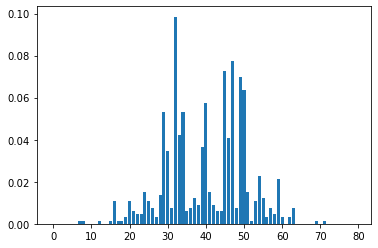

MCTS mode
Finished 1500 tree searches after 4.072483539581299s


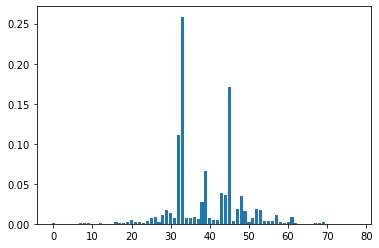

MCTS mode
Finished 1500 tree searches after 4.115459203720093s


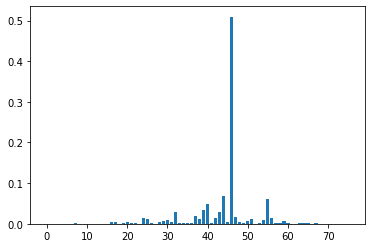

MCTS mode
Finished 1500 tree searches after 4.046507835388184s


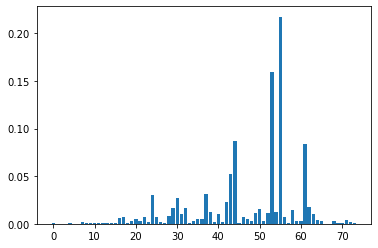

MCTS mode
Finishing early after 1440 tree searches


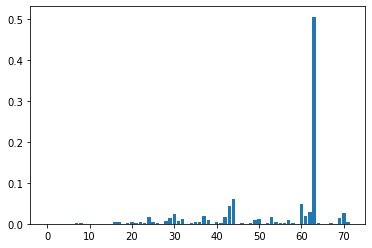

MCTS mode
Finished 1500 tree searches after 4.203404426574707s


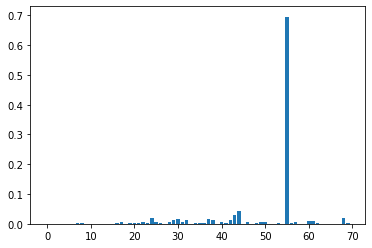

MCTS mode
Finished 1500 tree searches after 4.1754209995269775s


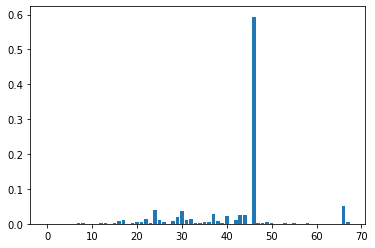

MCTS mode
Finished 1500 tree searches after 4.31233549118042s


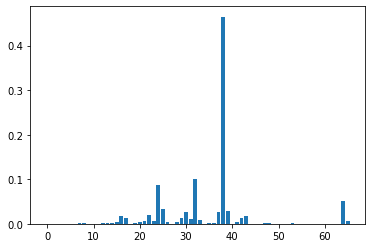

MCTS mode
Finished 1500 tree searches after 4.050497770309448s


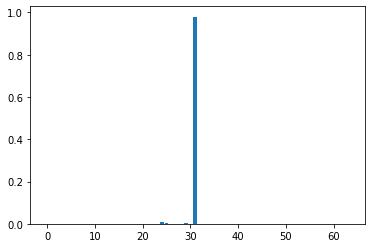

MCTS mode
Finished 1500 tree searches after 4.320332288742065s


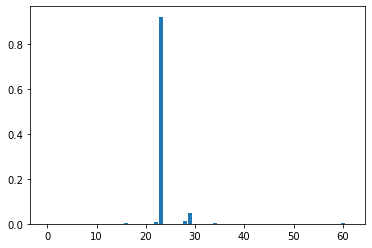

MCTS mode
Finishing early after 1350 tree searches


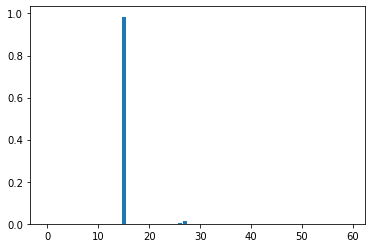

MCTS mode
Finished 1500 tree searches after 3.7816646099090576s


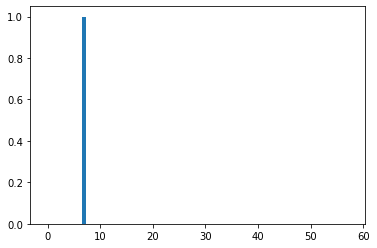

MCTS mode
Finished 1500 tree searches after 2.6313741207122803s


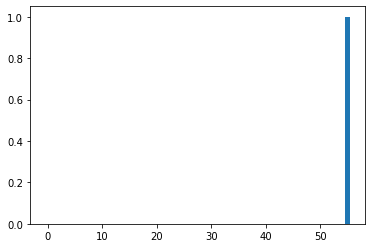

MCTS mode


In [4]:
from hex_minmax import *
from hex_nnet import *
from time import sleep
from threading import Thread, Lock

def threaded(func):
    """
    Decorator that multithreads the target function
    with the given parameters. Returns the thread
    created for the function
    """
    def wrapper(*args, **kwargs):
        thread = Thread(target=func, args=args)
        thread.start()
        return thread
    return wrapper

aicalcs = False
aidepth = 1

bsize = 9

# human player color (+1 is red, -1 is blue), ai will be the opposite
player = +1
rounds = 0

mouse_pos = np.zeros(2)
        


# Allows anti aliasing
config = pyglet.gl.Config(sample_buffers=1, samples=8)
window = pyglet.window.Window(config=config, resizable=True)

        
label = pyglet.text.Label(f'ai depth = {aidepth}',
                          font_name='Arial',
                          font_size=14,
                          color=(128,128,128,255),
                          x=window.width//2, y=0,
                          anchor_x='center', anchor_y='bottom')

def reset():
    global board, turn, over, path, wonby, resettime, ai, player, rounds
    # Initialization of the game
    board = np.zeros((bsize, bsize), 'int')
    turn = 1 # whos turn is it?
    over = False
    path = None # winning path if game ends
    wonby = 0
    resettime = None
    
    # AI
    #ai = MiniMax(timelimit=5)
    #ai = MiniMax(maxdepth=4)
    ai = MiniMax(maxdepth=1, heuristics=HexHeuristicsNNet())
    
    # Change human player color
    player = (-1)**rounds
    rounds += 1

    
reset()

    
def checkwon():
    global over, path, wonby, resettime
    if winner(board):
        wonby = winner(board)
        over = True
        path = winning_path(board)
        resettime = time() + 3


@window.event
def on_mouse_press(x, y, button, modifiers):
    if button == mouse.LEFT:
        global board, turn
        
        if turn != player:
            return
        
        N = len(board)
        # Scaling between coordinate x/y and screen x/y
        _xy_sc = _xy_off = 50 / (N/8)
        
        # Find cell the mouse clicked on
        x, y = (x-_xy_off)/_xy_sc, (y-_xy_off)/_xy_sc
        i, j = pos_on_board(x, y, bsize)
        if i is None:
            return
        
        # Check if game is over
        if over:
            return
        # Check if cell was already taken
        if board[i,j] != 0:
            return
        
        # Now take the cell
        board[i,j] = turn
        # Change current player
        turn *= -1
        checkwon()
        
        
        
@window.event
def on_mouse_motion(x, y, dx, dy):
    global mouse_pos
    mouse_pos = x, y
        
@window.event
def on_key_press(symbol, modifiers):
    global aidepth
    num = symbol - 48
    if 1<=num<=5:
        aidepth = num
        label.text = f'ai depth = {aidepth}'
        
        
minimax = None
def ai_minimax():
    global minimax
    if minimax is None:
        minimax = MiniMax()
    minimax.maxdepth = aidepth
    i, j = minimax.findmove(board, turn>0, verbose=3)
    return i, j
    
def ai_mixed():
    if np.sum(board!=0) <= 6:
        ai = MiniMax(maxdepth=1, heuristics=HexHeuristicsNNet())
    else:
        global minimax
        if minimax is None:
            minimax = MiniMax(maxdepth=aidepth)
        minimax.maxdepth = aidepth
        #ai = MiniMax(maxdepth=aidepth)
        ai = minimax
        
    i, j = ai.findmove(board, turn>0, verbose=3)
    return i, j
        
    
mcts = None
def ai_mcts():
    global mcts
    from hex_mcts import MultiMCTS
    if mcts is None:
        #mcts = MultiMCTS(net='net2.dat', nparallel=16, nsearches=500)
        mcts = MultiMCTS(net='net_selfplay150.dat', nparallel=16, nsearches=500, timelimit=5)
        mcts = MultiMCTS(net='net_selfplay150.dat', nparallel=1, nsearches=50, timelimit=5)
        from hex_net9x9 import NetAdaptive
        mcts = MultiMCTS(net=NetAdaptive('net_9x9.dat'), nparallel=30, nsearches=1500, timelimit=5, params={'useQ':True, 'cpuct':1})
    global board, turn, over, path, resettime
    if over: return
    
    mcts.clear()
    mcts.graph = ''
    i, j = mcts.findmove(board, verbose=1)
    plt.bar(range(len(mcts.policy)), mcts.policy)
    plt.show()
    return i, j
        
@threaded
def make_ai_move():
    global board, turn, aicalcs
    if over: return
    if aicalcs: return
    aicalcs = True
    
    #i, j = ai_minimax()
    #print('Minimax mode')
    #i, j = ai_mixed()
    #print('Mixed mode')
    i, j = ai_mcts()
    print('MCTS mode')
    
    # Now take the cell
    board[i,j] = turn
    # Change current player
    turn *= -1
    aicalcs = False
    checkwon()
    

@window.event
def on_draw():

    glClear(GL_COLOR_BUFFER_BIT)
    glEnable(GL_BLEND)
    glEnable(GL_LINE_SMOOTH)
    glHint(GL_LINE_SMOOTH_HINT, GL_DONT_CARE)
    
    if resettime:
        if time() > resettime:
            reset()

    show_board_gl(board, mouse_pos, path=path)
    label.draw()
    
    if turn != player and not aicalcs:
        make_ai_move()
        show_board_gl(board, mouse_pos, path=path, wonby=wonby)
        label.draw()
    
pyglet.app.run()


## Spieler gegen Spieler

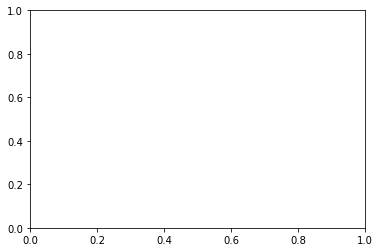

In [3]:
from time import time

bsize = 6

mouse_pos = np.zeros(2)

def reset():
    global board, turn, over, path, resettime
    # Initialization of the game
    board = np.zeros((bsize, bsize), 'int')
    turn = 1 # whos turn is it?
    over = False
    path = None # winning path if game ends
    resettime = None

reset()

# Allows anti aliasing
config = pyglet.gl.Config(sample_buffers=1, samples=8)
window = pyglet.window.Window(config=config, resizable=False) 


@window.event
def on_mouse_press(x, y, button, modifiers):
    if button == mouse.LEFT:
        global board, turn, over, path, resettime
        
        N = len(board)
        # Scaling between coordinate x/y and screen x/y
        _xy_sc = _xy_off = 50 / (N/8)
        
        # Find cell the mouse clicked on
        x, y = (x-_xy_off)/_xy_sc, (y-_xy_off)/_xy_sc
        i, j = pos_on_board(x, y, bsize)
        if i is None:
            return
        
        # Check if game is over
        if over:
            return
        # Check if cell was already taken
        if board[i,j] != 0:
            return
        
        # Now take the cell
        board[i,j] = turn
        # Change current player
        turn *= -1
        if winner(board):
            over = True
            path = winning_path(board)
            resettime = time() + 3
        
        
@window.event
def on_mouse_motion(x, y, dx, dy):
    global mouse_pos
    
    # Scaling between coordinate x/y and screen x/y
    xy_sc = xy_off = 50 / (bsize/8)
    
    mouse_pos = (x-xy_off)/xy_sc, (y-xy_off)/xy_sc
    mouse_pos = x, y
        
        
@window.event
def on_draw():

    # Clear buffers (necessary?)
    glClear(GL_COLOR_BUFFER_BIT)
    #glEnable(GL_BLEND)                                                            
    #glEnable(GL_LINE_SMOOTH)
    #glHint (GL_LINE_SMOOTH_HINT, GL_DONT_CARE)
    glColor3d(0.8, 0.0, 0.0)
    
    if resettime:
        if time() > resettime:
            reset()

    show_board_gl(board, mouse_pos, path=path)
    
    
pyglet.app.run()

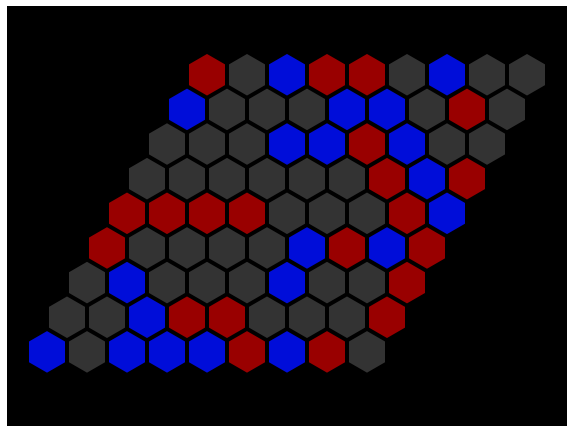

In [103]:
board=filledboard(9, .5)
show_board(board)

In [104]:
P, V = mcts.PV.nnet.predictStack([board])

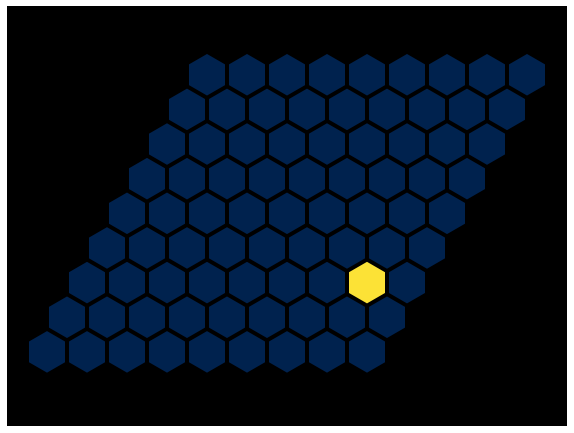

In [105]:
show_board(P[0], cmap='cividis')